In [3]:
from google.colab import files
uploaded = files.upload()

Saving layoffs.csv to layoffs (1).csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("layoffs.csv")

df.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Vimeo,New York City,NaN,4/3/2026,NaN,Consumer,https://hoodline.com/2026/04/vimeo-axes-quarte...,Post-IPO,450.0,United States,4/4/2026
1,Oracle,SF Bay Area,30000.0,3/31/2026,NaN,Other,https://www.cnbc.com/2026/03/31/oracle-layoffs...,Post-IPO,NaN,United States,3/31/2026
2,Monzo,"London, Non-U.S.",50.0,3/31/2026,NaN,Finance,https://www.bloomberg.com/news/articles/2026-0...,Series F,324.0,United Kingdom,3/31/2026
3,Covrzy,"Bengaluru, Non-U.S.",NaN,3/31/2026,1.0,Finance,https://inc42.com/buzz/antler-backed-covrzy-sh...,Seed,NaN,India,4/4/2026
4,Rec Room,Seattle,NaN,3/31/2026,1.0,Consumer,https://techcrunch.com/2026/03/31/social-gamin...,Series F,294.0,United States,4/1/2026


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4342 entries, 0 to 4341
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              4342 non-null   object 
 1   location             4341 non-null   object 
 2   total_laid_off       2842 non-null   float64
 3   date                 4342 non-null   object 
 4   percentage_laid_off  2731 non-null   float64
 5   industry             4340 non-null   object 
 6   source               4339 non-null   object 
 7   stage                4337 non-null   object 
 8   funds_raised         3847 non-null   float64
 9   country              4340 non-null   object 
 10  date_added           4342 non-null   object 
dtypes: float64(3), object(8)
memory usage: 373.3+ KB


In [7]:
df = df.drop(["company","location","source"], axis=1)

In [8]:
df.head()

,total_laid_off,date,percentage_laid_off,industry,stage,funds_raised,country,date_added
0,NaN,4/3/2026,NaN,Consumer,Post-IPO,450.0,United States,4/4/2026
1,30000.0,3/31/2026,NaN,Other,Post-IPO,NaN,United States,3/31/2026
2,50.0,3/31/2026,NaN,Finance,Series F,324.0,United Kingdom,3/31/2026
3,NaN,3/31/2026,1.0,Finance,Seed,NaN,India,4/4/2026
4,NaN,3/31/2026,1.0,Consumer,Series F,294.0,United States,4/1/2026


In [9]:
df = df.dropna()

In [10]:
df.shape

(1755, 8)

In [11]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year

df = df.drop("date", axis=1)

In [12]:
df = pd.get_dummies(df, columns=["industry","country","stage"])

In [13]:
df.head()

,total_laid_off,percentage_laid_off,funds_raised,date_added,year,industry_AI,industry_Aerospace,industry_Construction,industry_Consumer,industry_Crypto,...,stage_Series C,stage_Series D,stage_Series E,stage_Series F,stage_Series G,stage_Series H,stage_Series I,stage_Series J,stage_Subsidiary,stage_Unknown
8,700.0,0.01,26000.0,3/25/2026,2026,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
17,400.0,0.03,521.0,3/17/2026,2026,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19,1600.0,0.10,210.0,3/11/2026,2026,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30,4000.0,0.40,150.0,2/26/2026,2026,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
31,1000.0,0.05,2000.0,3/3/2026,2026,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [15]:
X = df.drop("total_laid_off", axis=1)
y = df["total_laid_off"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
df.columns

Index(['total_laid_off', 'percentage_laid_off', 'funds_raised', 'date_added',
       'year', 'industry_AI', 'industry_Aerospace', 'industry_Construction',
       'industry_Consumer', 'industry_Crypto', 'industry_Data',
       'industry_Education', 'industry_Energy', 'industry_Finance',
       'industry_Fitness', 'industry_Food', 'industry_HR', 'industry_Hardware',
       'industry_Healthcare', 'industry_Infrastructure', 'industry_Legal',
       'industry_Logistics', 'industry_Manufacturing', 'industry_Marketing',
       'industry_Media', 'industry_Other', 'industry_Product',
       'industry_Real Estate', 'industry_Recruiting', 'industry_Retail',
       'industry_Sales', 'industry_Security', 'industry_Support',
       'industry_Transportation', 'industry_Travel', 'country_Argentina',
       'country_Australia', 'country_Austria', 'country_Belgium',
       'country_Brazil', 'country_Canada', 'country_Cayman Islands',
       'country_Chile', 'country_China', 'country_Czech Republic',
   

In [19]:
df = df.drop("date_added", axis=1)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1755 entries, 8 to 4340
Data columns (total 92 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   total_laid_off                1755 non-null   float64
 1   percentage_laid_off           1755 non-null   float64
 2   funds_raised                  1755 non-null   float64
 3   year                          1755 non-null   int32  
 4   industry_AI                   1755 non-null   bool   
 5   industry_Aerospace            1755 non-null   bool   
 6   industry_Construction         1755 non-null   bool   
 7   industry_Consumer             1755 non-null   bool   
 8   industry_Crypto               1755 non-null   bool   
 9   industry_Data                 1755 non-null   bool   
 10  industry_Education            1755 non-null   bool   
 11  industry_Energy               1755 non-null   bool   
 12  industry_Finance              1755 non-null   bool   
 13  industry

In [21]:
X = df.drop("total_laid_off", axis=1)
y = df["total_laid_off"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [25]:
from sklearn.metrics import r2_score, mean_absolute_error


In [26]:
predictions = model.predict(X_test)

In [28]:
r2_score(y_test, predictions)

0.5365656046350796

In [29]:
mean_absolute_error(y_test, predictions)

244.8838028761362

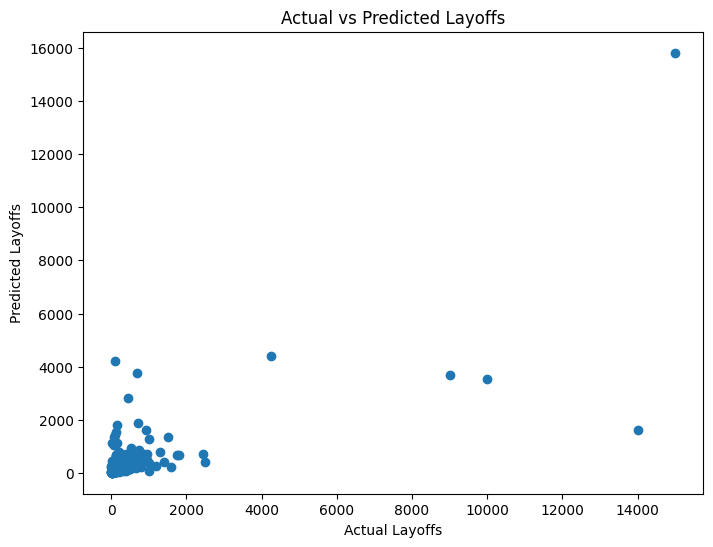

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Layoffs")
plt.ylabel("Predicted Layoffs")
plt.title("Actual vs Predicted Layoffs")
plt.show()

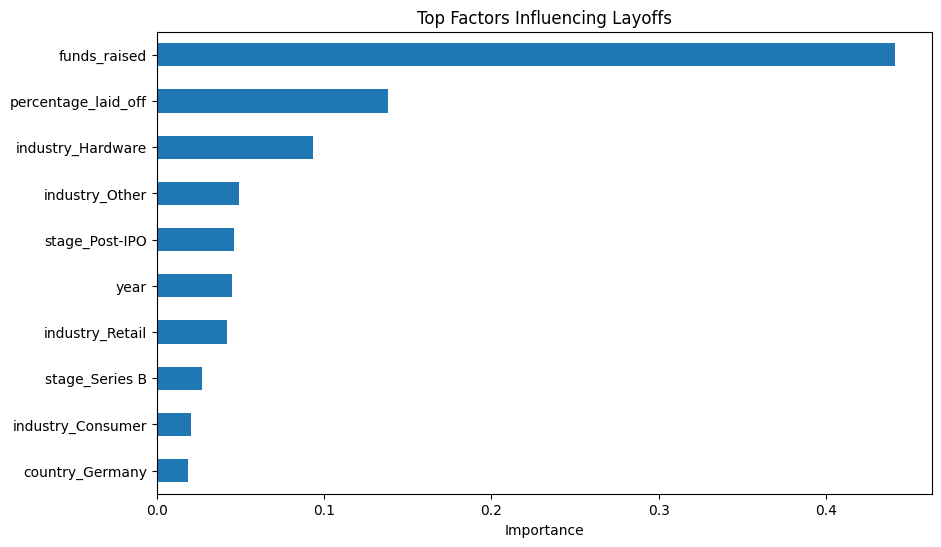

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(model.feature_importances_, index=X.columns)

top_features = feature_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_features.plot(kind='barh')
plt.title("Top Factors Influencing Layoffs")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()